C:\Users\fishb\AppData\Local\Temp\ipykernel_45004\580209133.py:34: RuntimeWarning: divide by zero encountered in divide
  ratio_0 = 2*delta_final_0/Tc_final_0
C:\Users\fishb\AppData\Local\Temp\ipykernel_45004\580209133.py:34: RuntimeWarning: invalid value encountered in divide
  ratio_0 = 2*delta_final_0/Tc_final_0
C:\Users\fishb\AppData\Local\Temp\ipykernel_45004\580209133.py:70: RuntimeWarning: invalid value encountered in divide
  ratio_0 = 2*delta_final_0/Tc_final_0
C:\Users\fishb\AppData\Local\Temp\ipykernel_45004\580209133.py:112: RuntimeWarning: invalid value encountered in divide
  ratio_1 = 2*delta_1/Tc_1
C:\Users\fishb\AppData\Local\Temp\ipykernel_45004\580209133.py:113: RuntimeWarning: invalid value encountered in divide
  ratio_2 = 2*delta_2/Tc_2


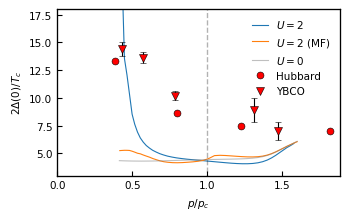

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.optimize import brentq
import time
import matplotlib.pyplot as plt

g = 0.8
Nk = 256

U = 2
Tc_final = np.load(f'Tc_U{U}_g{g}_N{Nk}_variational.npy')
x_final = np.load(f'x_U{U}_g{g}_N{Nk}_variational.npy')
delta_final = np.load(f'delta_U{U}_g{g}_N{Nk}_variational.npy')

U = 0
Tc_final_0 = np.load(f'Tc_U{U}_g{g}_N{Nk}_variational.npy')
x_final_0 = np.load(f'x_U{U}_g{g}_N{Nk}_variational.npy')
delta_final_0 = np.load(f'delta_U{U}_g{g}_N{Nk}_variational.npy')

mask = (delta_final !=0 )
Tc_final = Tc_final[mask]
x_final = x_final[mask]
delta_final = delta_final[mask]

mask_lower = x_final_0 >= 0.14
mask_upper = x_final_0 < 0.56
mask_ratio_0 = mask_lower & mask_upper

mask_lower = x_final >= 0.14
mask_upper = x_final < 0.56
mask_ratio = mask_lower & mask_upper

ratio_0 = 2*delta_final_0/Tc_final_0
ratio = 2*delta_final/Tc_final

ratio_0_plot = ratio_0[mask_ratio_0]
x_final_0_plot = x_final_0[mask_ratio_0]

ratio_plot = ratio[mask_ratio]
x_final_plot = x_final[mask_ratio]


g = 2
Nk = 256

U = 2
Tc_final = np.load(f'Tc_U{U}_g{g}_N{Nk}_variational.npy')
x_final = np.load(f'x_U{U}_g{g}_N{Nk}_variational.npy')
delta_final = np.load(f'delta_U{U}_g{g}_N{Nk}_variational.npy')

U=0
Tc_final_0 = np.load(f'Tc_U{U}_g{g}_N{Nk}_variational.npy')
x_final_0 = np.load(f'x_U{U}_g{g}_N{Nk}_variational.npy')
delta_final_0 = np.load(f'delta_U{U}_g{g}_N{Nk}_variational.npy')

mask = (delta_final !=0 )
Tc_final = Tc_final[mask]
x_final = x_final[mask]
delta_final = delta_final[mask]

mask_lower = x_final_0 >= 0.1
mask_upper = x_final_0 < 0.7
mask_ratio_0 = mask_lower & mask_upper

mask_lower = x_final >= 0.1
mask_upper = x_final < 0.7
mask_ratio = mask_lower & mask_upper

ratio_0 = 2*delta_final_0/Tc_final_0
ratio = 2*delta_final/Tc_final

ratio_0_plot_1 = ratio_0[mask_ratio_0]
x_final_0_plot_1 = x_final_0[mask_ratio_0]

ratio_plot_1 = ratio[mask_ratio]
x_final_plot_1 = x_final[mask_ratio]

g = 2
Nk = 512

U = 2
g = 2
Tc_1 = np.load(f'Tc_U{U}_g{g}_N{Nk}_mean.npy')
x_1 = np.load(f'x_U{U}_g{g}_N{Nk}_mean.npy')
delta_1 = np.load(f'delta_U{U}_g{g}_N{Nk}_mean.npy')

U = 2
g = 0.8
Tc_2 = np.load(f'Tc_U{U}_g{g}_N{Nk}_mean.npy')
x_2 = np.load(f'x_U{U}_g{g}_N{Nk}_mean.npy')
delta_2 = np.load(f'delta_U{U}_g{g}_N{Nk}_mean.npy')

#mask = (delta_1 !=0 )
#Tc_1 = Tc_final[mask]
#x_1 = x_final[mask]
#delta_1 = delta_final[mask]
#
#mask = (delta_2 !=0 )
#Tc_2 = Tc_final[mask]
#x_2 = x_final[mask]
#delta_2 = delta_final[mask]

mask_lower = x_1 >= 0.05
mask_upper = x_1 < 0.7
mask_1 = mask_lower & mask_upper

mask_lower = x_2 >= 0.142
mask_upper = x_2 < 0.56
mask_2 = mask_lower & mask_upper

ratio_1 = 2*delta_1/Tc_1
ratio_2 = 2*delta_2/Tc_2

ratio_1 = ratio_1[mask_1]
x_1 = x_1[mask_1]

ratio_2 = ratio_2[mask_2]
x_2 = x_2[mask_2]

optimal = 0.35

plt.style.use("publication.mplstyle")

fig, ax1 = plt.subplots()

# --- 第一部分：下 X 轴 & 左 Y 轴 ---
# 这里是你原有的绘图逻辑
ax1.plot(x_final_plot/optimal, ratio_plot*2, '-', label=r'$U=2$', color="C0")
#ax1.plot(x_final_plot_1, ratio_plot_1, '--', label='U=2,J=2', color="C0")
ax1.plot(x_2/optimal, ratio_2*2, '-', label=r'$U=2$ (MF)', color="C1")
#ax1.plot(x_1, ratio_1, '--', label='U=2,J=2 (MF)', color="C1")
ax1.plot(x_final_0_plot/optimal, ratio_0_plot*2, '-', label=r'$U=0$', color="gray", alpha=0.5)
#ax1.plot(x_final_0_plot_1, ratio_0_plot_1, '--', label='U=0,J=2', color="gray", alpha=0.5)

# 第一部分的辅助线
#ax1.plot([0.35, 0.35], [0, 10], color='black', linestyle=(0,(1,5)), linewidth=1, alpha=0.3)
ax1.plot([1, 1], [0, 30], color='black', linestyle='--', linewidth=1, alpha=0.3)

# 第一部分的坐标设置
ax1.set_xlabel(r'$p/p_c$')
ax1.set_ylabel(r'$2\Delta(0)/T_c$')
ax1.set_xlim(0.0, 0.66/0.35)
ax1.set_ylim(3, 18)
#ax1.set_yticks([2, 4, 6, 8, 10])
ax1.set_xticks([0, 0.5, 1, 1.5])


# --- 第二部分：上 X 轴 & 右 Y 轴 ---
# 1. 创建共享轴：先 twinx 得到右轴，再在右轴基础上 twiny 得到上轴
ax2_right = ax1.twinx()
ax2_top = ax2_right.twiny() 

# 2. 准备数据
x_Hubbard_2013 = [0.983, 0.965, 0.946, 0.92, 0.89]
doping_Hubbard_2013 = 1-np.array(x_Hubbard_2013)
T_Hubbard_2013 = [13.3, 8.6, 7.45, 7, 6.85]

# 3. 在对应的轴上绘图
# 注意：数据要画在 ax2_top 上，它同时继承了 ax2_right 的 Y 轴高度
ax2_top.plot(doping_Hubbard_2013, T_Hubbard_2013, 'o', 
             color='r', 
             label='Hubbard', 
             markeredgecolor='black', 
             markeredgewidth=0.4,
            ms=5)

# 第二部分的辅助线
#ax2_top.plot([0.044, 0.044], [5, 20], color='r', linestyle=(0,(1,5)), linewidth=1, alpha=0.3)

# 4. 第二部分的坐标设置
ax2_top.set_xlabel('p', color='r')
#ax2_right.set_ylabel(r'$2\Delta(0)/T_c$', color='r')
ax2_top.set_xlim(0.0, 0.083)
ax2_right.set_ylim(3, 18)
ax2_right.set_yticks([])

YBCO_2009_x = np.array([0.6,0.7,0.85])
YBCO_2009_doping = (YBCO_2009_x-0.3)/4.5/((1-0.3)/4.5)*0.044
YBCO_2009_ratio = np.array([14.4, 13.6, 10.2])
YBCO_error = np.array([0.6, 0.5, 0.4])

CAYBCO_2009_x = np.array([0.1,0.15])
CAYBCO_optimal = 0.16
CAYBCO_2009_doping = (CAYBCO_2009_x/2+CAYBCO_optimal)/CAYBCO_optimal*0.044
CAYBCO_2009_ratio = np.array([8.9, 7])
CAYBCO_error = np.array([1.1,0.8])

# 修改 YBCO 实验点的样式
ax2_top.errorbar(YBCO_2009_doping, YBCO_2009_ratio, 
                 fmt='v',                   # 格式字符串：'v' 代表倒三角且不连线
                 yerr=YBCO_error,           # Y轴误差数据
                 color='r', 
                 label='YBCO', 
                 alpha=1,
                 ms=6,                      # 标记大小
                 mec='black',               # 标记边框颜色 (markeredgecolor)
                 mew=0.4,                   # 标记边框粗细 (markeredgewidth)
                 ecolor='black',            # 误差棒线条颜色 (建议黑色或深红)
                 elinewidth=0.8,            # 误差棒中间线条的粗细
                 capsize=2,                 # 误差棒末端横杠的大小
                 capthick=0.8)              # 横杠的厚度

ax2_top.errorbar(CAYBCO_2009_doping, CAYBCO_2009_ratio, 
                 fmt='v',                   # 格式字符串：'v' 代表倒三角且不连线
                 yerr=CAYBCO_error,           # Y轴误差数据
                 color='r', 
                 #label='Ca-YBCO', 
                 alpha=1,
                 ms=6,                      # 标记大小
                 mec='black',               # 标记边框颜色 (markeredgecolor)
                 mew=0.4,                   # 标记边框粗细 (markeredgewidth)
                 ecolor='black',            # 误差棒线条颜色 (建议黑色或深红)
                 elinewidth=0.8,            # 误差棒中间线条的粗细
                 capsize=2,                 # 误差棒末端横杠的大小
                 capthick=0.8)              # 横杠的厚度


# --- 细节优化 ---
# 合并图例
# 1. 分别获取两个坐标轴的句柄和标签
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2_top.get_legend_handles_labels()

# 2. 关键步骤：遍历所有句柄，如果是 ErrorbarContainer，只取它的第一个线条元素
# 这样图例里就只剩下点（Marker），没有任何误差棒线条
cleaned_handles1 = [h[0] if hasattr(h, 'has_xerr') else h for h in handles1]
cleaned_handles2 = [h[0] if hasattr(h, 'has_xerr') else h for h in handles2]

# 3. 合并并绘制图例
ax1.legend(cleaned_handles1 + cleaned_handles2, labels1 + labels2, 
           loc='best', 
           handlelength=1.5,  # 缩短图例线条长度，显得更精致
           numpoints=1)       # 确保只有一个点


#ax1.legend(lines1 + lines2, labels1 + labels2, 
#           loc='upper right', 
#           bbox_to_anchor=(1.72, 1), 
#           ncol=1) # 如果想变短可以尝试 ncol=2，但通常右侧放 1 列最清晰

ax2_right.tick_params(axis='y', colors='red')
ax2_top.tick_params(axis='x', colors='red')
ax2_top.set_xlabel('')              # 清空 label
ax2_top.set_xticks([])              # 清空 刻度

#ax2_top.text(0.036, 1.04, 'Optimal', color='red', 
#             transform=ax2_top.get_xaxis_transform())
#ax2_top.text(0.009, 1.04, 'Underdoped', color='red', 
#             transform=ax2_top.get_xaxis_transform())
#ax2_top.text(0.057, 1.04, 'Overdoped', color='red', 
#             transform=ax2_top.get_xaxis_transform())
#ax2_top.text(-0.001, 1.04, '0', color='red', 
#             transform=ax2_top.get_xaxis_transform())


#plt.savefig('ratio_combined', bbox_inches='tight')
plt.show()